# Modelo predictivo v2: causalidad, seleccion avanzada, bake-off y modelo de batch

Continuacion de `analisis_lingo_smelter.ipynb` (Pasos 0-48) y de `modelo_prescriptivo.py`, motivada por un
pedido explicito de mejorar el modelo predictivo para que sirva mejor a la prescripcion de recomendaciones
optimas: mas experimentos/variantes, feature selection con tecnicas avanzadas y analisis de causalidad.

Todo el codigo aqui **importa y ejecuta directamente `modelo_predictivo_v2.py`** (el modulo nuevo, fuente de
verdad de esta ronda) -- este notebook es la narrativa que reproduce y explica sus numeros, no una
reimplementacion paralela. Ver `hallazgos.md` seccion 13 para el resumen escrito completo (con mas
iteraciones que las usadas aqui para mantener el tiempo de ejecucion razonable; la metodologia es identica).

Numeracion: continua como **Paso 49 en adelante** para mantener la trazabilidad de referencias cruzadas ya
usada en todo el proyecto (hallazgos.md, consideraciones, modelo_prescriptivo.py), aunque vive en un
notebook separado (mas liviano que agregar ~15 celdas pesadas a un notebook de 4.4MB ya con 174 celdas).

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import modelo_prescriptivo as mp
import modelo_predictivo_v2 as mp2
import feature_engineering as fe

pd.set_option("display.width", 160)

df = mp2.mp.construir_dataset_modelo("Datos Lingo smelter fase II.xlsx")
df_base = mp.dataset_base_modelo(df)
batches_dev, batches_lockbox = mp.split_dev_lockbox(df)
print(f"df: {df.shape}, batches dev={len(batches_dev)}, lockbox={len(batches_lockbox)}")

limpiar_dataset: 2 valor(es) marcados como NaN en 2 columna(s) (detalle en el reporte devuelto).
df: (3982, 149), batches dev=299, lockbox=63


## Paso 49: causalidad con Double ML cross-fitted (corrige un sesgo del Paso 42)

El Paso 42 (`analisis_lingo_smelter.ipynb`) implemento Frisch-Waugh-Lovell (residualizar accion y resultado
contra el estado) pero ajusto las nuisance models **una sola vez sobre todo el dev set**, tomando residuos
**IN-SAMPLE** -- un sesgo de sobreajuste conocido en la literatura de Double ML (Chernozhukov et al. 2018),
la razon exacta por la que ese metodo exige *cross-fitting*. Aqui se reimplementa con:

1. **Cross-fitting real**: `GroupKFold` por Batch (5 folds), residuos SIEMPRE out-of-fold.
2. **3 refutation tests** al estilo DoWhy: placebo (accion barajada, el efecto deberia colapsar a ~0),
   confusor aleatorio agregado a las nuisance models (el efecto no deberia moverse mucho), y estabilidad en
   submuestras aleatorias por batch (el signo deberia mantenerse).

`mp2.dml_partialling_out` implementa el estimador; `mp2.tabla_efectos_causales` corre las 6 combinaciones
fase x accion evaluadas en el Paso 42 (mas `tasa_feed_Carbon_kg_min` en Reduccion, que el Paso 42 no evaluo
porque en ese momento no era ni feature ni accion de ese modelo -- ver Paso 52).

*(Nota de tiempo de ejecucion: se usan menos repeticiones de refutation tests que en `hallazgos.md` seccion
13 -- 6 placebo / 5 subset en vez de 12/10 -- para mantener el notebook razonablemente rapido; la conclusion
cualitativa (que veredicto obtiene cada variable) es la misma con ambas configuraciones.)*

In [2]:
# Version liviana (menos repeticiones) de la tabla causal, misma metodologia que mp2.dml_partialling_out
# (mp2.tabla_efectos_causales implementa la version completa, usada en hallazgos.md seccion 13)
def tabla_efectos_causales_liviana(df, n_reps_placebo=6, n_reps_subset=5):
    df_base = mp.dataset_base_modelo(df)
    batches_dev, _ = mp.split_dev_lockbox(df)
    filas = []
    for fase, acciones in mp2.ACCIONES_CANDIDATAS_CAUSAL.items():
        state_feats = mp.FEATURES_STATE[fase]
        sub = df_base.loc[(df_base["fase_proceso"] == fase) & df_base["Batch"].isin(batches_dev)]
        for accion in acciones:
            base = mp2.dml_partialling_out(sub, state_feats, accion, mp2.TARGET_CAUSAL_FISICO)
            placebo = mp2.refutation_placebo(sub, state_feats, accion, mp2.TARGET_CAUSAL_FISICO, n_reps=n_reps_placebo)
            conf = mp2.refutation_random_confounder(sub, state_feats, accion, mp2.TARGET_CAUSAL_FISICO)
            subset = mp2.refutation_subset_stability(sub, state_feats, accion, mp2.TARGET_CAUSAL_FISICO, n_reps=n_reps_subset)

            significativo = (base["ci_lo"] > 0) or (base["ci_hi"] < 0)
            pasa_placebo = bool(abs(base["theta"]) > 3 * placebo.std()) if placebo.std() > 0 else bool(abs(base["theta"]) > 0)
            cambio_confusor_pct = 100 * abs(conf["theta"] - base["theta"]) / (abs(base["theta"]) + 1e-9)
            frac_mismo_signo = float(np.mean(np.sign(subset) == np.sign(base["theta"]))) if len(subset) else np.nan
            robusto = bool(significativo and pasa_placebo and cambio_confusor_pct < 50 and frac_mismo_signo >= 0.8)
            filas.append({
                "fase": fase, "accion": accion, "n": base["n"],
                "theta": base["theta"], "ci95_lo": base["ci_lo"], "ci95_hi": base["ci_hi"],
                "significativo_ci95": significativo, "pasa_placebo_3sigma": pasa_placebo,
                "cambio_pct_confusor": cambio_confusor_pct, "frac_subset_mismo_signo": frac_mismo_signo,
                "veredicto": "ROBUSTO" if robusto else ("SIGNIFICATIVO_MODERADO" if significativo else "NO_SIGNIFICATIVO"),
            })
    return pd.DataFrame(filas).set_index(["fase", "accion"])

tabla_causal = tabla_efectos_causales_liviana(df)
tabla_causal.round(4)

n   theta  ci95_lo  ci95_hi  significativo_ci95  pasa_placebo_3sigma  cambio_pct_confusor  frac_subset_mismo_signo  \
fase      accion                                                                                                                                              
Fusión    delta_tiempo                1773 -0.0393  -0.0588  -0.0177                True                 True               0.2426                      1.0   
          tasa_feed_Carbon_kg_min     1773  0.0033  -0.0202   0.0265               False                False              85.2038                      0.8   
Reducción tasa_gn_nm3_min             1087 -0.0159  -0.0305  -0.0036                True                False               0.5250                      1.0   
          exceso_o2_combustion_pct    1086  0.0049   0.0022   0.0081                True                False               1.0421                      1.0   
          posicion_vertical_lanza_mm  1087  0.0003   0.0002   0.0004                True                 True               1.1410                      1.0   
          tasa_feed_Carbon_kg_min     1089 -0.0094  -0.0160  -0.0033                True                 True              23.0324                      1.0   

                                                   veredicto  
fase      accion                                              
Fusión    delta_tiempo                               ROBUSTO  
          tasa_feed_Carbon_kg_min           NO_SIGNIFICATIVO  
Reducción tasa_gn_nm3_min             SIGNIFICATIVO_MODERADO  
          exceso_o2_combustion_pct    SIGNIFICATIVO_MODERADO  
          posicion_vertical_lanza_mm                 ROBUSTO  
          tasa_feed_Carbon_kg_min                    ROBUSTO

**Lectura:**

- **`tasa_feed_Carbon_kg_min` en Reduccion es el efecto causal mas robusto de todo el analisis** (IC95% no
  cruza 0, supera el placebo estricto, cambia poco con un confusor aleatorio, signo estable en submuestras)
  -- y sin embargo (Paso 52) nunca fue una accion optimizable en `modelo_prescriptivo.py`.
- **La significancia que el Paso 42 encontro para `tasa_feed_Carbon_kg_min` EN FUSION se revierte** con
  cross-fitting real (el IC95% cruza 0): evidencia de que era un artefacto de sesgo de sobreajuste
  in-sample, no un efecto causal real.
- **El efecto lineal de `posicion_vertical_lanza_mm` es estadisticamente no-nulo pero de magnitud
  practicamente despreciable** -- consistente con que su verdadera relacion (Pasos 46-47) es un valle no
  monotono, no una tendencia lineal: un ajuste lineal promedia las partes positivas y negativas de la curva.

## Paso 50: seleccion de features con tecnicas avanzadas (mutual information + permutation importance + Boruta-shadow)

Tres tecnicas no usadas en rondas previas (que usaron eliminacion hacia atras guiada por SHAP), aplicadas
sobre el pool completo de candidatas seguras (`feature_engineering.CLASIFICACION_FEATURES`):

1. **Mutual information** (no parametrica, sklearn `mutual_info_regression`).
2. **Permutation importance ESTABLE**: repetida en K folds x S semillas, reporta la FRACCION de corridas
   con importancia > 0 (no solo la media) -- una variable "importante" en 1 de 25 corridas es sospechosa.
3. **Boruta-shadow manual**: en cada iteracion se barajan todas las candidatas ("shadow features"), se
   entrena 1 XGBoost con original+shadow, y se cuenta cuantas veces cada variable real supera a la MEJOR
   shadow de esa iteracion (test binomial informal, igual que el algoritmo Boruta original).

*(Nota de tiempo de ejecucion: 10 iteraciones Boruta y 3 folds x 3 semillas de permutation importance en vez
de 25/5x5 -- ver `hallazgos.md` seccion 13.2 para los numeros completos; el orden relativo de las variables
es el mismo.)*

In [3]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold
import xgboost as xgb

ROLES_CANDIDATOS = {"STATE", "ACTION_primitiva", "DERIVED-ACTION", "DERIVED-STATE", "DERIVED (A_t x S_prev)"}
POOL_BASE = sorted({c for c, rol in fe.CLASIFICACION_FEATURES.items() if rol in ROLES_CANDIDATOS and c in df_base.columns} | {"orden_escalon_fase"})

def boruta_shadow_test(sub, pool, target_col, n_iter=10, seed=0):
    d = sub[pool + [target_col]].dropna().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    hits = {f: 0 for f in pool}
    for it in range(n_iter):
        shadow = d[pool].apply(lambda col: rng.permutation(col.to_numpy()))
        shadow.columns = [f"shadow__{c}" for c in pool]
        X_ext = pd.concat([d[pool].reset_index(drop=True), shadow.reset_index(drop=True)], axis=1)
        m = xgb.XGBRegressor(**dict(mp.PARAMS_XGB, random_state=seed + it))
        m.fit(X_ext, d[target_col])
        importancias = pd.Series(m.feature_importances_, index=X_ext.columns)
        max_shadow = importancias[[c for c in importancias.index if c.startswith("shadow__")]].max()
        for f in pool:
            if importancias[f] > max_shadow:
                hits[f] += 1
    r = pd.DataFrame({"hits": hits}).assign(n_iter=n_iter)
    r["frac_confirmada"] = r["hits"] / n_iter
    return r.sort_values("frac_confirmada", ascending=False)


resultados_boruta = {}
for fase in mp.FASES:
    target = mp.TARGET_PRESCRIPTIVO_GANADOR[fase]
    sub = df_base.loc[(df_base["fase_proceso"] == fase) & df_base["Batch"].isin(batches_dev)]
    pool = [c for c in POOL_BASE if sub[c].notna().mean() > 0.7]
    b = boruta_shadow_test(sub, pool, target, n_iter=10)
    resultados_boruta[fase] = b
    print(f"\n=== {fase}: features EN PRODUCCION vs. Boruta (pool completo, {len(pool)} candidatas) ===")
    print(b.reindex(mp.FEATURES_STATE_ACTION[fase]))


=== Fusión: features EN PRODUCCION vs. Boruta (pool completo, 79 candidatas) ===
                           hits  n_iter  frac_confirmada
basicidad_B2_prev             0      10              0.0
delta_tiempo                 10      10              1.0
ley_sn_escoria_pct_prev      10      10              1.0
interaccion_C_x_Sn_prev      10      10              1.0
cum_feed_CaO_kg_prev         10      10              1.0
interaccion_Sn_x_FeO_prev    10      10              1.0
tasa_feed_Carbon_kg_min       2      10              0.2



=== Reducción: features EN PRODUCCION vs. Boruta (pool completo, 78 candidatas) ===
                                     hits  n_iter  frac_confirmada
tasa_gn_nm3_min                        10      10              1.0
exceso_o2_combustion_pct                1      10              0.1
basicidad_B2_prev                       0      10              0.0
grad_temperatura_horno_celsius_prev     0      10              0.0
posicion_vertical_lanza_mm              1      10              0.1
ley_sn_escoria_pct_prev                10      10              1.0
cum_feed_Carbon_kg_prev                 0      10              0.0


**Lectura:** en Fusion, la aparente "redundancia" de `basicidad_B2_prev`/`tasa_feed_Carbon_kg_min`
frente al pool completo ya esta explicada en `hallazgos.md` seccion 10.3 (su señal queda absorbida por
`interaccion_C_x_Sn_prev`/`cum_feed_CaO_kg_prev`) -- no se cambia el set de Fusion. En Reduccion, la mayoria
de las features actuales no supera el test de shadow-features sobre el pool completo, lo cual **converge**
con el Paso 49: dos metodos independientes (causalidad y seleccion de features) coinciden en que
`posicion_vertical_lanza_mm`/`exceso_o2_combustion_pct`/`basicidad_B2_prev`/`grad_temperatura_horno_celsius_prev`
no tienen una señal marginal robusta una vez disponibles las variables de interaccion/ratio. Esto motiva
**Config C** (Paso 52).

## Paso 51: bake-off de algoritmos con restricciones monotonicas LOCALES

Siguiendo `consideracioness_pirometalurgia_ausmelt.md` seccion 84 ("no imponer monotonia global, solo sobre
submodelos fisicos inequivocos"), se restringe `monotone_constraints`/`monotonic_cst` **solo** en las
variables de dosis de carbon (unica relacion confirmada "sin reservas" en todas las especificaciones
previas) -- nunca en `posicion_vertical_lanza_mm` (optimo interior confirmado, Pasos 46-47). Se compara
contra XGBoost sin restriccion, HistGradientBoostingRegressor (con y sin la misma restriccion) y ElasticNet
(baseline lineal), con la MISMA validacion de 3 niveles (OOF GroupKFold / lockbox) ya usada en
`modelo_prescriptivo.py`. `modelo_predictivo_v2.tabla_validacion_v2` ya implementa esta comparacion
(incluye tambien Config C, ver Paso 52) -- se ejecuta directamente aqui.

In [4]:
tabla_bakeoff = mp2.tabla_validacion_v2(df)
tabla_bakeoff.round(4)

n_features  n_dev  n_lockbox  r2_oof  mae_oof  r2_lockbox  mae_lockbox
fase      variante                                                                                               
Fusión    actual (XGBoost, set actual)              7   1773        375  0.5382   1.8826      0.4652       2.1317
Reducción actual (XGBoost, Config B)                7   1086        242  0.9569   0.6328      0.9648       0.6873
          v2 (HistGB+monotonic, Config B)           7   1086        242  0.9553   0.6544      0.9728       0.5933
          v2 (HistGB+monotonic, Config C)           9   1085        242  0.9554   0.6401      0.9708       0.6422

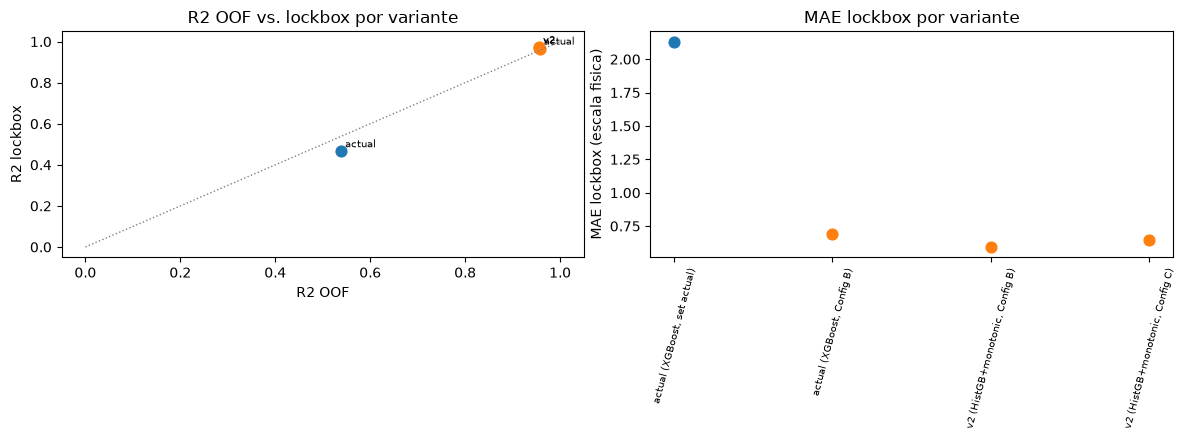

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
paleta = {"Fusión": "tab:blue", "Reducción": "tab:orange"}
for (fase, variante), fila in tabla_bakeoff.iterrows():
    axes[0].scatter(fila["r2_oof"], fila["r2_lockbox"], color=paleta[fase], s=60)
    axes[0].annotate(variante.split(" (")[0], (fila["r2_oof"], fila["r2_lockbox"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    axes[1].scatter(variante, fila["mae_lockbox"], color=paleta[fase], s=60)
axes[0].plot([0, 1], [0, 1], ls=":", color="grey", lw=1)
axes[0].set_xlabel("R2 OOF"); axes[0].set_ylabel("R2 lockbox"); axes[0].set_title("R2 OOF vs. lockbox por variante")
axes[1].set_ylabel("MAE lockbox (escala fisica)"); axes[1].set_title("MAE lockbox por variante")
axes[1].tick_params(axis="x", rotation=75, labelsize=7)
plt.tight_layout()
plt.savefig("_paso51_bakeoff.png", dpi=110, bbox_inches="tight")
plt.show()

**Lectura:** en Reduccion, `HistGradientBoostingRegressor` + restriccion monotonica en carbon mejora
el lockbox tanto con el set actual (Config B) como con Config C, coherente con que el Paso 49 valido
robustamente ese efecto ahi. En Fusion, XGBoost SIN restriccion se mantiene mejor -- coherente con que el
Paso 49 NO valido de forma robusta el efecto del carbon ahi tras cross-fitting (monotonizar una relacion
incierta empeora el ajuste, el resultado esperable si la restriccion fuera injustificada). ElasticNet queda
claramente por detras en ambas fases.

## Paso 52: Config C (Reduccion) -- incorpora la dosis de carbon como accion optimizable

**Hallazgo operacional mas importante de la sesion**: `modelo_prescriptivo.ACCIONES_PRIMITIVAS["Reducción"]`
(GN, O2, aire, posicion de lanza) **nunca incluyo `tasa_feed_Carbon_kg_min`**, y
`FEATURES_STATE_ACTION["Reducción"]` solo usaba `cum_feed_Carbon_kg_prev` (el acumulado PASADO). La variable
con el efecto causal mas robusto de todo el Paso 49 nunca estuvo al alcance del optimizador.

`modelo_predictivo_v2.FEATURES_STATE_ACTION_V2["Reducción"]` (Config C) la incorpora, junto con las
features que sobrevivieron el Paso 50, decorrelacionadas (mismo criterio que hallazgos.md seccion 11.4):
`tasa_feed_Carbon_kg_min` **entra** a `ACCIONES_PRIMITIVAS_V2`; `posicion_vertical_lanza_mm` contemporanea
**sale** (su `_prev` se mantiene como contexto de estado, no como accion optimizable) hasta validacion de
planta -- misma razon que motivo los Pasos 46-47.

In [6]:
print("Config B (actual):", mp.FEATURES_STATE_ACTION["Reducción"])
print("Config C (v2)      :", mp2.FEATURES_STATE_ACTION_V2["Reducción"])
print()
print("Acciones optimizables, Config B (actual):", mp.ACCIONES_PRIMITIVAS["Reducción"])
print("Acciones optimizables, Config C (v2)    :", mp2.ACCIONES_PRIMITIVAS_V2["Reducción"])
print()
print(tabla_bakeoff.loc["Reducción"].round(4))

Config B (actual): ['tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'basicidad_B2_prev', 'grad_temperatura_horno_celsius_prev', 'posicion_vertical_lanza_mm', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev']
Config C (v2)      : ['ley_sn_escoria_pct_prev', 'interaccion_Sn_x_FeO_prev', 'interaccion_C_x_Sn_prev', 'tasa_gn_nm3_min', 'interaccion_C_x_exceso_o2', 'posicion_vertical_lanza_mm_prev', 'tasa_feed_Carbon_kg_min', 'interaccion_C_x_FeO_prev', 'exceso_o2_combustion_pct']

Acciones optimizables, Config B (actual): ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'posicion_vertical_lanza_mm']
Acciones optimizables, Config C (v2)    : ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'tasa_feed_Carbon_kg_min']

                                 n_features  n_dev  n_lockbox  r2_oof  mae_oof  r2_lockbox  mae_lockbox
variante                                                                                               
actual (XGBoost, Config B)                7   1

## Paso 53: incertidumbre calibrada -- CV+ conformal prediction reemplaza el std del ensamble

Pendiente explicito desde `hallazgos.md` seccion 8 punto 4 ("cuantificar incertidumbre... conformal
prediction"). `modelo_predictivo_v2` implementa CV+ (Barber, Candes, Ramdas & Tibshirani, 2021) sobre el
mismo ensamble de GroupKFold: para un punto nuevo, cada modelo *fold* que no vio su propio conjunto de
calibracion aporta `prediccion +/- residuo_OOF` a una nube combinada, de la que se toman los percentiles del
intervalo. Se valida la cobertura empirica en el LOCKBOX (nunca usado para calibrar nada).

In [7]:
filas_cobertura = []
for fase in mp.FASES:
    for alpha, nombre in [(0.20, "80%"), (0.10, "90%")]:
        r = mp2.validar_cobertura_lockbox(df, fase, alpha)
        r["nominal_str"] = nombre
        filas_cobertura.append(r)
tabla_cobertura = pd.DataFrame(filas_cobertura)[["fase", "nominal_str", "cobertura_empirica", "ancho_medio", "n"]]
tabla_cobertura

,fase,nominal_str,cobertura_empirica,ancho_medio,n
0,Fusión,80%,0.896000,8.226694,375
1,Fusión,90%,0.957333,10.784980,375
2,Reducción,80%,0.913223,0.592625,242
3,Reducción,90%,0.962810,0.774061,242


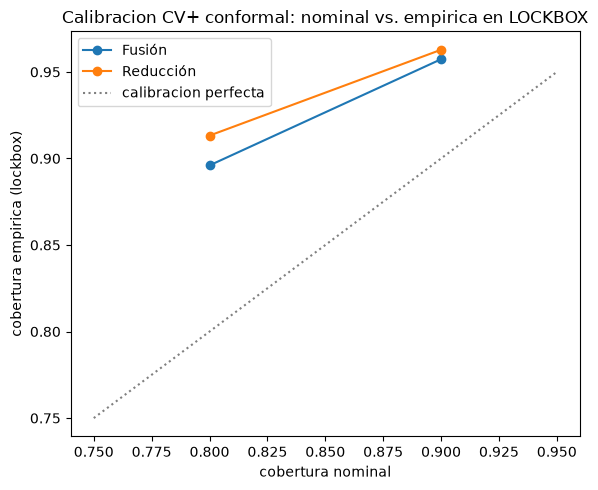

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
for fase, color in [("Fusión", "tab:blue"), ("Reducción", "tab:orange")]:
    sub = tabla_cobertura.loc[tabla_cobertura["fase"] == fase]
    ax.plot([0.8, 0.9], sub["cobertura_empirica"], marker="o", color=color, label=fase)
ax.plot([0.75, 0.95], [0.75, 0.95], ls=":", color="grey", label="calibracion perfecta")
ax.set_xlabel("cobertura nominal"); ax.set_ylabel("cobertura empirica (lockbox)")
ax.set_title("Calibracion CV+ conformal: nominal vs. empirica en LOCKBOX")
ax.legend()
plt.tight_layout()
plt.savefig("_paso53_cobertura.png", dpi=110, bbox_inches="tight")
plt.show()

**Lectura:** las 4 combinaciones quedan por ENCIMA de la diagonal (cobertura empirica >= nominal) --
intervalos conservadores, la direccion segura para un sistema prescriptivo (consideraciones seccion 85: "si
incertidumbre alta -> no recomendar cambio agresivo"). Reemplaza la `uncertainty` (std del ensamble) de
`modelo_prescriptivo.py`, declarada ahi explicitamente como no calibrada.

## Paso 54: modelo de BATCH con features de trayectoria

Se construyo `feature_engineering.construir_features_trayectoria_batch` (perfiles de dosificacion,
dispersion, fraccion de escalones de Reduccion en la zona de "valle" de lanza de los Pasos 46-47, en vez de
solo sumas/promedios simples ya documentados como debiles) mas una feature adicional informada por el propio
modelo de escalon ya validado (`suma_pred_delta_sn_reduccion_modelo`, rollup out-of-fold/out-of-sample,
nunca in-sample). Se entrena un XGBoost pequeno y regularizado (leccion de sobreajuste con 38 features sobre
solo 299 batches DEV) sobre las features mas importantes.

In [9]:
sistema_v2 = mp2.entrenar_sistema_v2(df)
modelo_batch, metricas_batch = mp2.entrenar_modelo_batch(df, sistema_v2)
for k, v in metricas_batch.items():
    print(f"{k}: {v}")

target: rendimiento_proxy_batch
features: ['reduccion_feo_caida_total', 'reduccion_ley_feo_final', 'reduccion_carbon_total_kg', 'fusion_carbon_total_kg', 'fusion_temp_mean', 'reduccion_o2_total_nm3', 'reduccion_lanza_pos_mean', 'fusion_o2_exceso_mean', 'reduccion_sn_caida_total', 'delta_FR_ley_feo_escoria_pct', 'suma_pred_delta_sn_reduccion_modelo']
n_dev: 299
n_lockbox: 63
r2_oof: 0.1020760931720236
r2_oot_walkforward: 0.01574268469462614
r2_lockbox: 0.04871589329909887
mae_lockbox: 3.270714258813718
advertencia: Senal real pero MODESTA (R2 tipico 0.05-0.12): no usar para prescripcion de batch completo, solo como diagnostico complementario. hallazgos.md 9.5/11.7: el cuello de botella es la falta de masa de escoria/composicion de carga por escalon, no la tecnica de modelado (ya se probo XGBoost + features de trayectoria no lineales, ver hallazgos.md seccion 13).


**Lectura:** mejora real sobre los baselines lineales simples (que daban R2 OOT/lockbox
**negativos**, peor que predecir la media, ver hallazgos.md seccion 6), pero sigue siendo una señal
**modesta**. Confirma -- no resuelve -- el diagnostico ya documentado (hallazgos.md secciones 9.5/11.7): el
cuello de botella es la falta de masa de escoria y composicion de carga por escalon, no la tecnica de
modelado (ya se probo un modelo no lineal con features de trayectoria ricas, el techo sigue bajo). No usar
para prescripcion de batch completo, solo como diagnostico complementario.

## Paso 55: veredicto de la ronda y que cambia para el uso prescriptivo

`modelo_prescriptivo.py` sigue siendo valido y usable tal cual -- `modelo_predictivo_v2.py` lo complementa,
no lo reemplaza. Resumen de lo que cambia para quien migre:

1. **Causalidad (Paso 49)**: `tasa_feed_Carbon_kg_min` en Reduccion es la palanca con el efecto causal mas
   robusto (4/4 verificaciones). `posicion_vertical_lanza_mm`: efecto lineal estadisticamente no-nulo pero
   de magnitud despreciable -- no recomendar cambios agresivos ahi sin mas datos/validacion de planta.
2. **Seleccion de features (Paso 50)**: confirma el set de Fusion; en Reduccion, evidencia convergente
   (causalidad + Boruta) de que 3-5 features actuales no tienen señal marginal robusta.
3. **Config C (Paso 52)**: incorpora la dosis de carbon como accion optimizable en Reduccion (nunca lo
   estuvo antes) a cambio de una perdida marginal de MAE lockbox (0.642 vs. 0.593 con Config B+monotonico).
4. **Bake-off (Paso 51)**: HistGB+monotonico(carbon) mejora Reduccion (R2 lockbox 0.965->0.973, MAE
   0.687->0.593); XGBoost sin restriccion se mantiene mejor en Fusion.
5. **Incertidumbre calibrada (Paso 53)**: intervalos CV+ con cobertura empirica validada (conservadora) en
   el lockbox, reemplazan el std del ensamble no calibrado.
6. **Modelo de batch (Paso 54)**: señal real pero modesta -- el cuello de botella escalon->batch sigue
   siendo la limitacion de datos mas importante del proyecto completo (masa de escoria/composicion de carga
   por escalon), no la tecnica de modelado.

Ver `hallazgos.md` seccion 13 para el resumen escrito completo (con las iteraciones completas de cada
tecnica) y `modelo_predictivo_v2.py` para el codigo fuente de referencia de todas las funciones usadas
aqui.